# Question 3 Random Walk Task

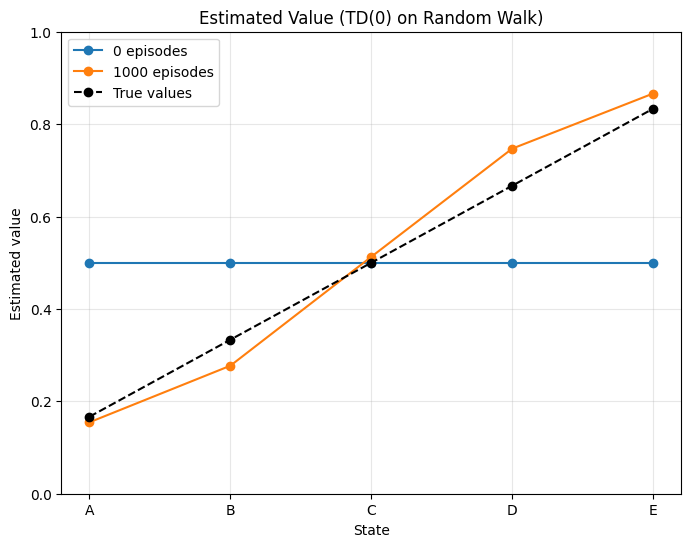

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class RandomWalk:
    def __init__(self):
        """Initialize the 5-state Random Walk MRP."""
        self.states = ['A', 'B', 'C', 'D', 'E']
        self.terminal_states = ['left_terminal', 'right_terminal']

    def reset(self):
        """Reset the environment to the start state (C)."""
          # TODO: Implement state reset

        self.current_state = 'C'
        return self.current_state

    def step(self, action):
        """Take a step in the environment.
        
        Args:
            action (int): -1 for left, +1 for right.
        
        Returns:
            next_state (str): The next state.
            reward (float): Reward received.
            done (bool): Whether the episode has ended.
        """
        # TODO: Implement transition dynamics

        idx = self.states.index(self.current_state)
        next_idx = idx + action
        #handle left terminal
        if next_idx < 0:
            next_state = 'left_terminal'
            reward = 0
            done = True
        #handle right terminal
        elif next_idx >= len(self.states):
            next_state = 'right_terminal'
            reward = 1
            done = True
        #just get to the next state
        else:
            next_state = self.states[next_idx]
            reward = 0
            done = False
        
        self.current_state = next_state
        return next_state, reward, done



class TDLearner:
    def __init__(self, alpha=0.1):
        """Initialize the TD(0) learning algorithm."""
        self.alpha = alpha
        self.value_function = {
            'A': 0.5, 'B': 0.5, 'C': 0.5, 'D': 0.5, 'E': 0.5,
            'left_terminal': 0.0, 'right_terminal': 0.0
        }
    
    def update(self, state, reward, next_state):
        """Perform a TD(0) update step.
        
        Args:
            state (str): Current state.
            reward (float): Reward received.
            next_state (str): Next state after transition.
        """
        #apply the TD 0 Equation directly 
        td_target = reward + self.value_function[next_state]
        td_error = td_target - self.value_function[state]
        self.value_function[state] += self.alpha * td_error

def run_experiment(num_episodes=1000):
    """Run the Random Walk experiment with TD(0)."""
    env = RandomWalk()
    agent = TDLearner(alpha=0.1)
    
    for episode in range(num_episodes):
        state = env.reset()
        done = False
        while not done:
            action = np.random.choice([-1, 1])  # Random left or right move
            next_state, reward, done = env.step(action)
            agent.update(state, reward, next_state)
            state = next_state
    
    return agent.value_function  # Return learned values

def plot_results(estimated_values):
    """Plot estimated values against true values."""
    states = ['A', 'B', 'C', 'D', 'E']
    true_values = [1/6, 2/6, 3/6, 4/6, 5/6]
    est = [estimated_values[s] for s in states]
    
    plt.figure(figsize=(8, 6))
    plt.plot(states, [0.5]*5, marker='o', label='0 episodes')
    plt.plot(states, est, marker='o', label='1000 episodes')
    plt.plot(states, true_values, marker='o', linestyle='--', color='black', label='True values')
    plt.xlabel('State')
    plt.ylabel('Estimated value')
    plt.title('Estimated Value (TD(0) on Random Walk)')
    plt.legend()
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.show()


if __name__ == "__main__":
    estimated_values = run_experiment()
    plot_results(estimated_values)

# Question 4 Windy Gridworld Domain

In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [3]:
class WindyGridWorld(object):
    def __init__(self, enable_king_move=False, enable_no_move=False, stochastic_wind=False):
        # define the grid space
        self.grid = np.zeros((7, 10))

        # define the state space
        self.state_space = [[r, c] for r, c in zip(np.where(self.grid == 0.0)[0],
                                                   np.where(self.grid == 0.0)[1])]

        # define the start state
        self.start_state = [3, 0]

        # define the goal state
        self.goal_state = [3, 7]

        # define the wind
        self.wind = np.array([0, 0, 0, 1, 1, 1, 2, 2, 1, 0], dtype=int)

        # define the action space
        self.action_space = {
            "up": np.array([-1, 0]),
            "down": np.array([1, 0]),
            "left": np.array([0, -1]),
            "right": np.array([0, 1])
        }
        
        # Enable King's moves (Comment out the above action space to create a new one for King's moves)
        if enable_king_move:
            
            if enable_no_move:
               #TODO
               # all action space if no move
               self.action_space = {
                    "up":         np.array([-1,  0]),
                    "down":       np.array([ 1,  0]),
                    "left":       np.array([ 0, -1]),
                    "right":      np.array([ 0,  1]),
                    "up-left":    np.array([-1, -1]),
                    "up-right":   np.array([-1,  1]),
                    "down-left":  np.array([ 1, -1]),
                    "down-right": np.array([ 1,  1]),
                    "no-move":    np.array([ 0,  0])
                }
                
            else:
                #actions for each case if move
                self.action_space = {
                    "up":         np.array([-1,  0]),
                    "down":       np.array([ 1,  0]),
                    "left":       np.array([ 0, -1]),
                    "right":      np.array([ 0,  1]),
                    "up-left":    np.array([-1, -1]),
                    "up-right":   np.array([-1,  1]),
                    "down-left":  np.array([ 1, -1]),
                    "down-right": np.array([ 1,  1])
                }
        #         #TODO

        #
        else:
        #     #TODO
            #all of the actions in grid world 4 actions 
            self.action_space = {
                "up":    np.array([-1, 0]),
                "down":  np.array([1, 0]),
                "left":  np.array([0, -1]),
                "right": np.array([0, 1])
            }
            
         
        # track the current state, time step, and action
        self.state = None
        self.t = None
        self.act = None

        self.stochastic_wind = stochastic_wind



    def reset(self):
        # reset the agent to the start state
        self.state = self.start_state
        # reset the time step tracker
        self.t = 0
        # reset the action tracker
        self.act = None
        # reset the terminal flag
        terminated = False
        return self.state, terminated

    def step(self, act):

        #TODO
        # get actions
        action_vec = list(self.action_space.values())[act]

        wind_effect = self.wind[self.state[1]]

        #stochastic wind
        if self.stochastic_wind and wind_effect != 0:
            wind_effect += np.random.choice([-1, 0, 1])

        #get location in griwworld deterministic
        next_row = self.state[0] + action_vec[0] - wind_effect
        next_col = self.state[1] + action_vec[1] 

        #handle grid world bounds
        next_row = max(0, min(next_row, self.grid.shape[0] - 1))        
        next_col = max(0, min(next_col, self.grid.shape[1] - 1))  

        #update state
        self.state = [next_row, next_col]
        self.act = act
        self.t += 1
        
        #reward for each action
        reward = -1

        terminated = (self.state == self.goal_state)

        return self.state, reward, terminated

    def render(self):
        # plot the agent and the goal
        # agent = 1
        # goal = 2
        plot_arr = self.grid.copy()
        plot_arr[self.state[0], self.state[1]] = 1.0
        plot_arr[self.goal_state[0], self.goal_state[1]] = 2.0
        plt.clf()
        fig, arr = plt.subplots(1, 1)
        arr.set_title(f"state={self.state}, act={self.act}")
        arr.imshow(plot_arr)
        plt.show(block=False)
        plt.pause(1)
        plt.close(fig)


In [4]:
class SARSA(object):
    def __init__(self, env, alpha, epsilon, gamma, timeout):
        # define the parameters
        self.alpha = alpha
        self.epsilon = epsilon
        self.gamma = gamma

        # environment
        self.env = env

        # define the Q value table
        self.state_num = len(self.env.state_space)
        self.action_num = len(self.env.action_space.keys())
        self.Q = np.zeros((self.state_num, self.action_num))

        # define the timeout
        self.timeout = timeout

    def behavior_policy(self, state):
        #TODO
        state_idx = self.env.state_space.index(state)
        #epslion greedy action 
        if np.random.random() < self.epsilon:
            return np.random.randint(self.action_num)

        else:
            return np.argmax(self.Q[state_idx])

        return None

    def update(self, s, a, r, s_prime, a_prime):
        #TODO
        s_idx = self.env.state_space.index(s)
        s_prime_idx = self.env.state_space.index(s_prime)

        td_target = r + self.gamma * self.Q[s_prime_idx, a_prime]

        td_error = td_target - self.Q[s_idx, a]
        self.Q[s_idx, a] += self.alpha * td_error
        
    def rollout(self):
        pass
        return None

    def run(self):
         # episodes[t] = number of episodes completed by time step t
        episodes = np.zeros(self.timeout)
        episode_count = 0
        t = 0
        while t < self.timeout:
            state, terminated = self.env.reset()
            action = self.behavior_policy(state)
            while not terminated and t < self.timeout:
                next_state, reward, terminated = self.env.step(action)
                if terminated:
                    # terminal state: Q(terminal, .) = 0
                    s_idx = self.env.state_space.index(state)
                    self.Q[s_idx, action] += self.alpha * (reward - self.Q[s_idx, action])
                    episode_count += 1
                    episodes[t] = episode_count
                    t += 1
                else:
                    next_action = self.behavior_policy(next_state)
                    self.update(state, action, reward, next_state, next_action)
                    episodes[t] = episode_count
                    t += 1
                    state = next_state
                    action = next_action
        return episodes
        

In [5]:
class ExpectedSARSA(object):
    def __init__(self, env, alpha, epsilon, gamma, timeout):
        # define the parameters
        self.alpha = alpha
        self.epsilon = epsilon
        self.gamma = gamma

        # environment
        self.env = env

        # define the Q value table
        self.state_num = len(self.env.state_space)
        self.action_num = len(self.env.action_space.keys())
        self.Q = np.zeros((self.state_num, self.action_num))

        # define the timeout
        self.timeout = timeout

    def behavior_policy(self, state):
        
    #same as above for epsilon greedy
        state_idx = self.env.state_space.index(state)
        if np.random.random() < self.epsilon:
            return np.random.randint(self.action_num)
        else:
            return np.argmax(self.Q[state_idx])
            
    def update(self, s, a, r, s_prime, a_prime):
        #TODO
        s_idx = self.env.state_space.index(s)
        s_prime_idx = self.env.state_space.index(s_prime)
        #compute expected value under epsilon greedy policy
        q_s_prime = self.Q[s_prime_idx]
        best_action = np.argmax(q_s_prime)
        expected_q = 0.0

        for a_i in range(self.action_num):
            if a_i == best_action:
                expected_q += (1 - self.epsilon + self.epsilon / self.action_num) * q_s_prime[a_i]
            else:
                expected_q += (self.epsilon / self.action_num) * q_s_prime[a_i]
        
        # do the td error and target and update q value for s,a 
        td_target = r + self.gamma * expected_q
        td_error = td_target - self.Q[s_idx, a]
        self.Q[s_idx, a] += self.alpha * td_error
    
    def rollout(self):
        pass

    def run(self):
        #TODO
        episodes = np.zeros(self.timeout)
        episode_count = 0
        t = 0
        #until end of epiosde
        while t < self.timeout:
            state, terminated = self.env.reset()
            action = self.behavior_policy(state)

            while not terminated and t < self.timeout:

                next_state, reward, terminated = self.env.step(action)
                #termination condition update epiosde cound and q value
                if terminated:
                    s_idx = self.env.state_space.index(state)
                    self.Q[s_idx, action] += self.alpha * (reward - self.Q[s_idx, action])
                    episode_count += 1
                    episodes[t] = episode_count
                    t += 1
                #if not go next action
                else:
                    next_action = self.behavior_policy(next_state)
                    self.update(state, action, reward, next_state, next_action)
                    episodes[t] = episode_count
                    t += 1
                    state = next_state
                    action = next_action

        return episodes

In [6]:
class QLearning(object):
    def __init__(self, env, alpha, epsilon, gamma, timeout):
        # define the parameters
        self.alpha = alpha
        self.epsilon = epsilon
        self.gamma = gamma

        # environment
        self.env = env

        # define the Q value table
        self.state_num = len(self.env.state_space)
        self.action_num = len(self.env.action_space.keys())
        self.Q = np.zeros((self.state_num, self.action_num))
    
        # define the timeout
        self.timeout = timeout

    def behavior_policy(self, state):
        #TODO
        #same aas above epsilon greedy
        state_idx = self.env.state_space.index(state)
        if np.random.random() < self.epsilon:
            return np.random.randint(self.action_num)
        else:
            return np.argmax(self.Q[state_idx])

    def update(self, s, a, r, s_prime):
        #TODO
        s_idx = self.env.state_space.index(s)
        s_prime_idx = self.env.state_space.index(s_prime)

        td_target = r + self.gamma * np.max(self.Q[s_prime_idx])
        td_error = td_target - self.Q[s_idx, a]

        self.Q[s_idx, a] += self.alpha * td_error

    def rollout(self):
        pass

    def run(self):
        #TODO
        episodes = np.zeros(self.timeout)
        episode_count = 0
        t = 0

        while t < self.timeout:
            state, terminated = self.env.reset()

            while not terminated and t < self.timeout:
                action = self.behavior_policy(state)
                next_state, reward, terminated = self.env.step(action)
                 #termination condition update epiosde cound and q value
                if terminated:
                    s_idx = self.env.state_space.index(state)
                    self.Q[s_idx, action] += self.alpha * (reward - self.Q[s_idx, action])
                    episode_count += 1
                    episodes[t] = episode_count
                    t += 1
                #if not go next action
                else:
                    self.update(state, action, reward, next_state)
                    episodes[t] = episode_count
                    t += 1
                    state = next_state
        return episodes


In [7]:
# addded the mc method here 

class MonteCarloControl(object):
    def __init__(self, env, alpha, epsilon, gamma, timeout):
        # define the parameters
        self.alpha = alpha
        self.epsilon = epsilon
        self.gamma = gamma

        # environment
        self.env = env

        # define the Q value table
        self.state_num = len(self.env.state_space)
        self.action_num = len(self.env.action_space.keys())
        self.Q = np.zeros((self.state_num, self.action_num))

        # define the timeout
        self.timeout = timeout

    def behavior_policy(self, state):
        #epsilon greedy action
        state_idx = self.env.state_space.index(state)
        if np.random.random() < self.epsilon:
            return np.random.randint(self.action_num)
        else:
            return np.argmax(self.Q[state_idx])

    def update(self, s, a, G):
        #mc update: move Q toward full return G
        s_idx = self.env.state_space.index(s)
        mc_error = G - self.Q[s_idx, a]
        self.Q[s_idx, a] += self.alpha * mc_error

    def rollout(self):
        pass

    def run(self):
        # episodes[t] = number of episodes completed by time step t
        episodes = np.zeros(self.timeout)
        episode_count = 0
        t = 0

        while t < self.timeout:
            # collect full episode trajectory first
            trajectory = []
            state, terminated = self.env.reset()
            while not terminated and t + len(trajectory) < self.timeout:
                action = self.behavior_policy(state)
                next_state, reward, terminated = self.env.step(action)
                trajectory.append((state, action, reward))
                state = next_state

            steps = len(trajectory)
            if t + steps > self.timeout:
                break

            # compute returns and update Q backwards (first visit)
            G = 0
            visited = set()
            for s, a, r in reversed(trajectory):
                #accumulate discounted return
                G = r + self.gamma * G
                s_idx = self.env.state_space.index(s)
                #first visit mc only
                if (s_idx, a) not in visited:
                    visited.add((s_idx, a))
                    self.update(s, a, G)

            episode_count += 1
            #fill timesteps used by this episode
            for i in range(steps):
                episodes[t + i] = episode_count
            t += steps

        return episodes

In [8]:
def plot_curves(arr_list, legend_list, color_list, ylabel):
    """
    Args:
        arr_list (list): list of results arrays to plot
        legend_list (list): list of legends corresponding to each result array
        color_list (list): list of color corresponding to each result array
        ylabel (string): label of the Y axis

    Make sure the elements in the arr_list, legend_list, and color_list are associated with each other correctly.
    Do not forget to change the ylabel for different plots.
    """
    # Clear the current figure
    plt.clf()
    fig, ax = plt.subplots(figsize=(12, 8))

    # Set labels
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Time Steps")

    # Plot results
    h_list = []
    for arr, legend, color in zip(arr_list, legend_list, color_list):
        # Compute the mean and standard error while ignoring NaN values
        mean_arr = np.nanmean(arr, axis=0)
        arr_err = np.nanstd(arr, axis=0) / np.sqrt(np.sum(~np.isnan(arr), axis=0))
        
        # Plot the mean
        h, = ax.plot(range(len(mean_arr)), mean_arr, color=color, label=legend)
        
        # Plot the confidence band
        arr_err = 1.96 * arr_err  # 95% confidence interval
        ax.fill_between(range(len(mean_arr)),
                        mean_arr - arr_err,
                        mean_arr + arr_err,
                        alpha=0.3, color=color)
        # Save the plot handle
        h_list.append(h)

    # Set the title (adjust as needed)
    ax.set_title("Windy Gridworld Results")
    ax.legend(handles=h_list)
    plt.show()

In [9]:
def run_on_policy_td_control(run_num, timeout):
    
    enable_king_move_actions = False
    enable_no_move_actions = False
    
    # create the environment
    env = WindyGridWorld(enable_king_move=enable_king_move_actions, enable_no_move=enable_no_move_actions)

    # parameters
    epsilon = 0.1
    alpha = 0.5
    gamma = 1.0

    # create the expected SARSA
    expected_sarsa_results_list = []
    for _ in range(run_num):
        # run for each trial
        controller_expected_sarsa = ExpectedSARSA(env, alpha, epsilon, gamma, timeout)
        episodes = controller_expected_sarsa.run()
        # append the results
        expected_sarsa_results_list.append(episodes[0:8000])
        
    # create the SARSA
    sarsa_results_list = []
    for _ in range(run_num):
        # run for each trial
        controller_sarsa = SARSA(env, alpha, epsilon, gamma, timeout)
        episodes = controller_sarsa.run()
        # append the results
        sarsa_results_list.append(episodes[0:8000])

    # create the Q learning
    q_learning_results_list = []
    for _ in range(run_num):
        # run for each trial
        controller_q_learning = QLearning(env, alpha, epsilon, gamma, timeout)
        episodes = controller_q_learning.run()
        # append the results
        q_learning_results_list.append(episodes[0:8000])

    
    # create the mc 
    mc_results_list = []
    for _ in range(run_num):
        # run for each trial
        controller_mc = MonteCarloControl(env, alpha, epsilon, gamma, timeout)
        episodes = controller_mc.run()
        # append the results
        mc_results_list.append(episodes[0:8000])

    
    
    sarsa_array = np.array(sarsa_results_list)
    expected_sarsa_array = np.array(expected_sarsa_results_list)
    q_learning_array = np.array(q_learning_results_list)

    #add mc 
    mc_array = np.array(mc_results_list)
    
    # Plot the results (modified for MC)
    plot_curves(
        [sarsa_array, expected_sarsa_array, q_learning_array, mc_array],
        ['SARSA', 'Expected SARSA', 'Q-learning', 'Monte Carlo'],
        ['r', 'b', 'g', 'm'],
        "Episodes"
    )

<Figure size 640x480 with 0 Axes>

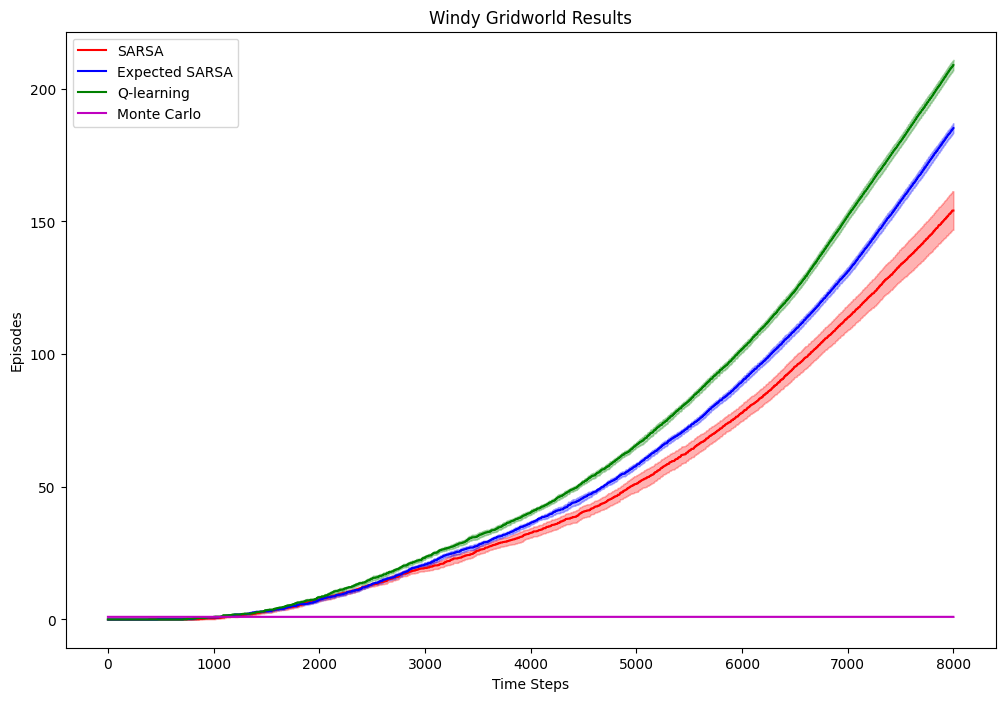

In [10]:
if __name__ == "__main__":
    # set randomness
    np.random.seed(1234)
    random.seed(1234)

    # trial number
    trial_num = 10
    # maximal time steps
    max_time_steps = 8000
    
    
    # run SARSA and Q Learning
    run_on_policy_td_control(trial_num, max_time_steps)

<Figure size 640x480 with 0 Axes>

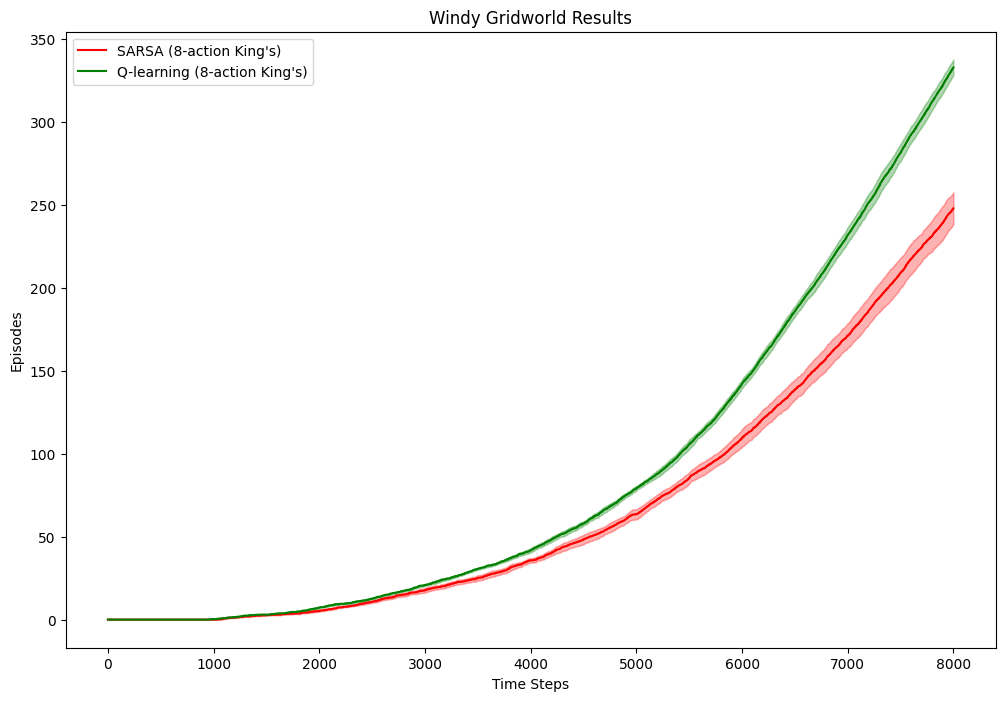

<Figure size 640x480 with 0 Axes>

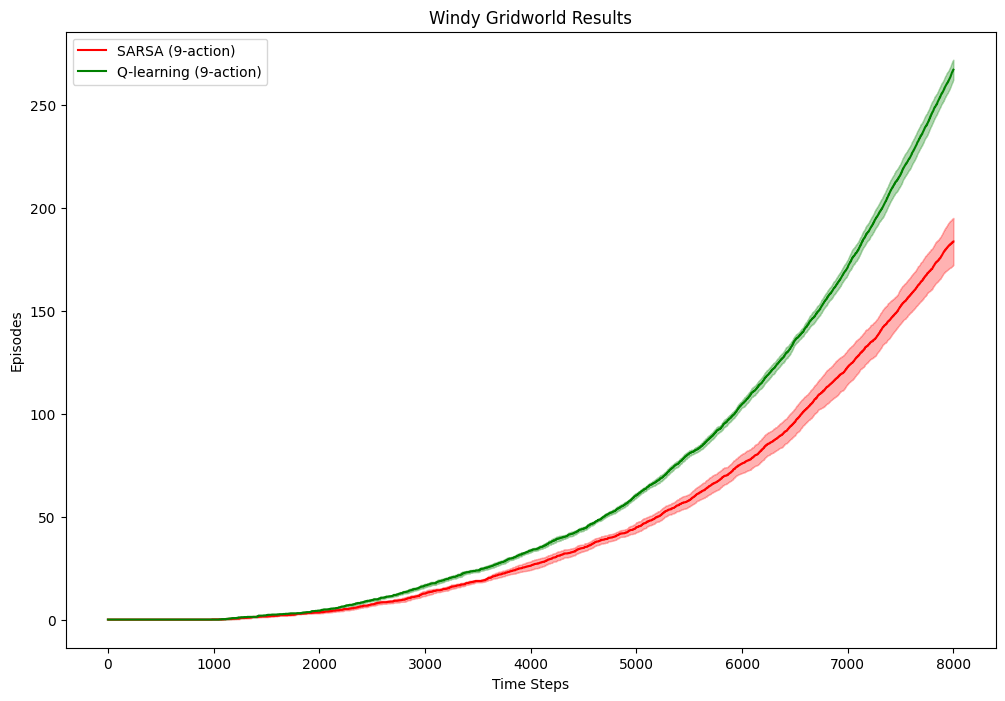

In [11]:
#4(c) kings moves - 8 actions and optional 9th no move action
def run_kings_moves(run_num, timeout, enable_no_move=False):
    #create env with kings moves
    env = WindyGridWorld(enable_king_move=True, enable_no_move=enable_no_move)
    epsilon, alpha, gamma = 0.1, 0.5, 1.0

    sarsa_results, q_results = [], []
    for _ in range(run_num):
        #run sarsa trials
        ep = SARSA(env, alpha, epsilon, gamma, timeout).run()
        sarsa_results.append(ep[:8000])
    for _ in range(run_num):
        #run q learning trials
        ep = QLearning(env, alpha, epsilon, gamma, timeout).run()
        q_results.append(ep[:8000])

    label = "9-action" if enable_no_move else "8-action King's"
    plot_curves(
        [np.array(sarsa_results), np.array(q_results)],
        [f'SARSA ({label})', f'Q-learning ({label})'],
        ['r', 'g'],
        "Episodes"
    )

if __name__ == "__main__":
    np.random.seed(1234); random.seed(1234)
    run_kings_moves(10, 8000, enable_no_move=False)  #8 actions
    run_kings_moves(10, 8000, enable_no_move=True)   #9 actions with no move


<Figure size 640x480 with 0 Axes>

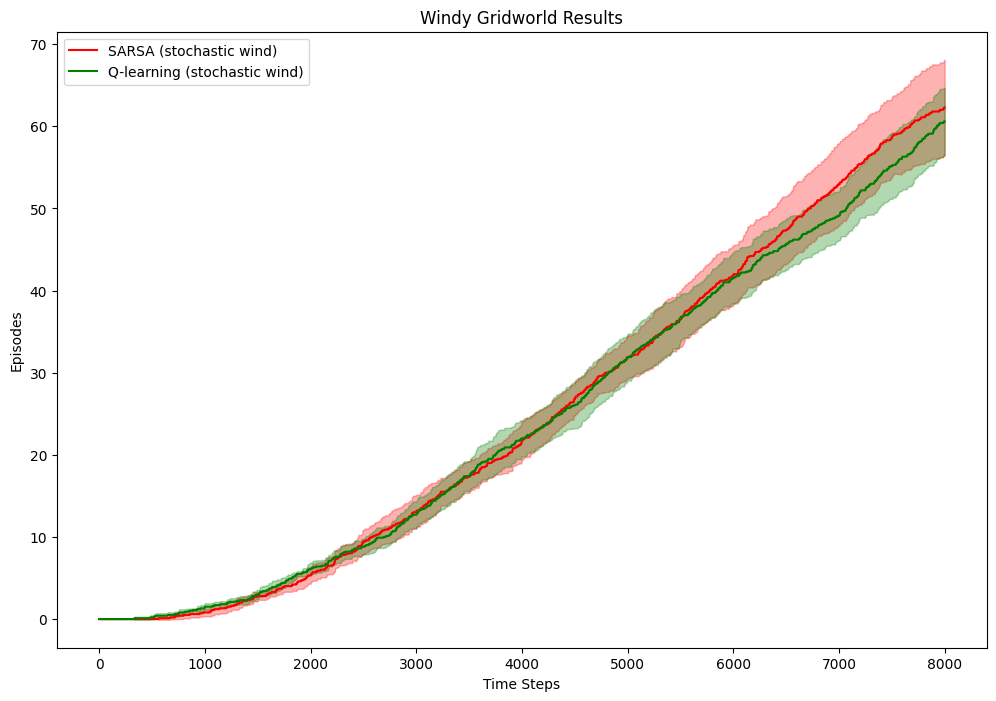

In [12]:
#4(d) stochastic wind with kings moves
def run_stochastic_wind(run_num, timeout):
    #create env with kings moves and stochastic wind
    env = WindyGridWorld(enable_king_move=True, enable_no_move=False,
                         stochastic_wind=True)
    epsilon, alpha, gamma = 0.1, 0.5, 1.0

    sarsa_results, q_results = [], []
    for _ in range(run_num):
        ep = SARSA(env, alpha, epsilon, gamma, timeout).run()
        sarsa_results.append(ep[:8000])
    for _ in range(run_num):
        ep = QLearning(env, alpha, epsilon, gamma, timeout).run()
        q_results.append(ep[:8000])

    plot_curves(
        [np.array(sarsa_results), np.array(q_results)],
        ['SARSA (stochastic wind)', 'Q-learning (stochastic wind)'],
        ['r', 'g'],
        "Episodes"
    )

if __name__ == "__main__":
    np.random.seed(1234); random.seed(1234)
    run_stochastic_wind(10, 8000)


# Question 4
- Please refer to starter code from question 4 to help you get started. You will create your own TD(0) and Monte Carlo classes.
- We will continue with the original windy gridworld domain. 
- A fixed policy π will be specified to collect episodes.
- A certain number of “training” episodes N ∈ {1, 10, 50} will be collected.
- Each method being investigated ( On-policy TD(0), On-policy Monte-Carlo prediction) will learn to      estimate the state-value.
function using the N “training“ episodes, respectively.
- We then evaluate the distribution of learning targets each method experiences at a specified state S. In
this question, S is the initial state marked as S in the Example 6.5.
- To do so, you need to collect additional 100 “evaluation” episodes. Instead of using these to perform
further updates to the state-value function, we will instead evaluate the distribution of learning targets
V(S) based on the “evaluation” episodes. For example, TD(0) will experience a set of {R+ V(S′)} targets,
whereas Monte-Carlo will experience a set of {G} targets.
- Note that in practice you should pre-collect both the training and evaluation episodes for efficiency and to
ensure consistency while comparing between different methods.

In [13]:
def run_on_policy_mc_td_epsilon_greedy_windy_gridworld():
    enable_king_move_actions = False
    enable_no_move_actions = False
    
    # create environments
    env = WindyGridWorld(enable_king_move=enable_king_move_actions,
                         enable_no_move=enable_no_move_actions)
    env.reset()

    epsilon, alpha, gamma = 0.1, 0.5, 1.0
    n_step = 5  #n-step TD step size (between TD0 and MC)

    #train sarsa to get a near optimal policy
    sarsa = SARSA(env, alpha, epsilon, gamma, timeout=50000)
    sarsa.run()
    policy_Q = sarsa.Q

    #fixed epsilon greedy policy using trained Q table
    def fixed_policy(state):
        idx = env.state_space.index(state)
        if np.random.random() < epsilon:
            return np.random.randint(len(env.action_space))
        return int(np.argmax(policy_Q[idx]))

    #collect n full episodes using fixed policy
    def collect_episodes(n):
        episodes = []
        for _ in range(n):
            traj = []
            state, done = env.reset()
            while not done:
                a = fixed_policy(state)
                next_state, r, done = env.step(a)
                traj.append((state, a, r, next_state))
                state = next_state
            episodes.append(traj)
        return episodes

    start_state = env.start_state
    N_values = [1, 10, 50]
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))  #3 methods x 3 N values = 9 histograms
    fig.suptitle("Bias-Variance: Learning Targets at Start State S")

    for col, N in enumerate(N_values):
        #pre collect training and evaluation episodes
        train_eps = collect_episodes(N)
        eval_eps  = collect_episodes(100)

        #td0 learn value function from training episodes
        n_states = len(env.state_space)
        V_td = np.zeros(n_states)
        for ep in train_eps:
            for (s, a, r, s_next) in ep:
                si      = env.state_space.index(s)
                si_next = env.state_space.index(s_next)
                #apply td0 update
                V_td[si] += alpha * (r + gamma * V_td[si_next] - V_td[si])

        #mc learn value function from training episodes
        V_mc    = np.zeros(n_states)
        returns = [[] for _ in range(n_states)]
        for ep in train_eps:
            G = 0
            for (s, a, r, s_next) in reversed(ep):
                #accumulate return backwards
                G = r + gamma * G
                si = env.state_space.index(s)
                returns[si].append(G)
        for si in range(n_states):
            if returns[si]:
                V_mc[si] = np.mean(returns[si])

        #collect learning targets at start state from eval episodes
        s_idx = env.state_space.index(start_state)
        td_targets, mc_targets, nstep_targets = [], [], []

        for ep in eval_eps:
            #td target is R + V(S') at first visit to start state
            for (s, a, r, s_next) in ep:
                if s == start_state:
                    si_next = env.state_space.index(s_next)
                    td_targets.append(r + gamma * V_td[si_next])
                    break
            #mc target is full return G from first visit to start state
            G, found = 0, False
            for (s, a, r, s_next) in reversed(ep):
                G = r + gamma * G
                if s == start_state:
                    found = True
            if found:
                mc_targets.append(G)
            #n-step TD target at first visit to start state
            for t, (s, a, r, s_next) in enumerate(ep):
                if s == start_state:
                    G = 0
                    for k in range(n_step):
                        if t + k < len(ep):
                            G += (gamma ** k) * ep[t + k][2]
                    last_idx = min(t + n_step, len(ep) - 1)
                    last_s_next = ep[last_idx][3]
                    si_last = env.state_space.index(last_s_next)
                    G += (gamma ** n_step) * V_td[si_last]
                    nstep_targets.append(G)
                    break

        #plot histograms for td, n-step td, and mc
        ax_td     = axes[0, col]
        ax_nstep  = axes[1, col]
        ax_mc     = axes[2, col]

        ax_td.hist(td_targets, bins=20, color='steelblue', edgecolor='k', alpha=0.8)
        ax_td.axvline(V_td[s_idx], color='red', linestyle='--', label=f'V_TD={V_td[s_idx]:.1f}')
        ax_td.set_title(f'TD(0), N={N}')
        ax_td.set_xlabel("R + V(S')")
        ax_td.legend()

        ax_nstep.hist(nstep_targets, bins=20, color='mediumseagreen', edgecolor='k', alpha=0.8)
        ax_nstep.set_title(f'n-step TD (n={n_step}), N={N}')
        ax_nstep.set_xlabel('n-step return')

        ax_mc.hist(mc_targets, bins=20, color='darkorange', edgecolor='k', alpha=0.8)
        ax_mc.axvline(V_mc[s_idx], color='red', linestyle='--', label=f'V_MC={V_mc[s_idx]:.1f}')
        ax_mc.set_title(f'MC, N={N}')
        ax_mc.set_xlabel('G (return)')
        ax_mc.legend()

        if col == 0:
            axes[0, col].set_ylabel('TD(0) Count')
            axes[1, col].set_ylabel('n-step TD Count')
            axes[2, col].set_ylabel('MC Count')

    plt.tight_layout()
    plt.show()


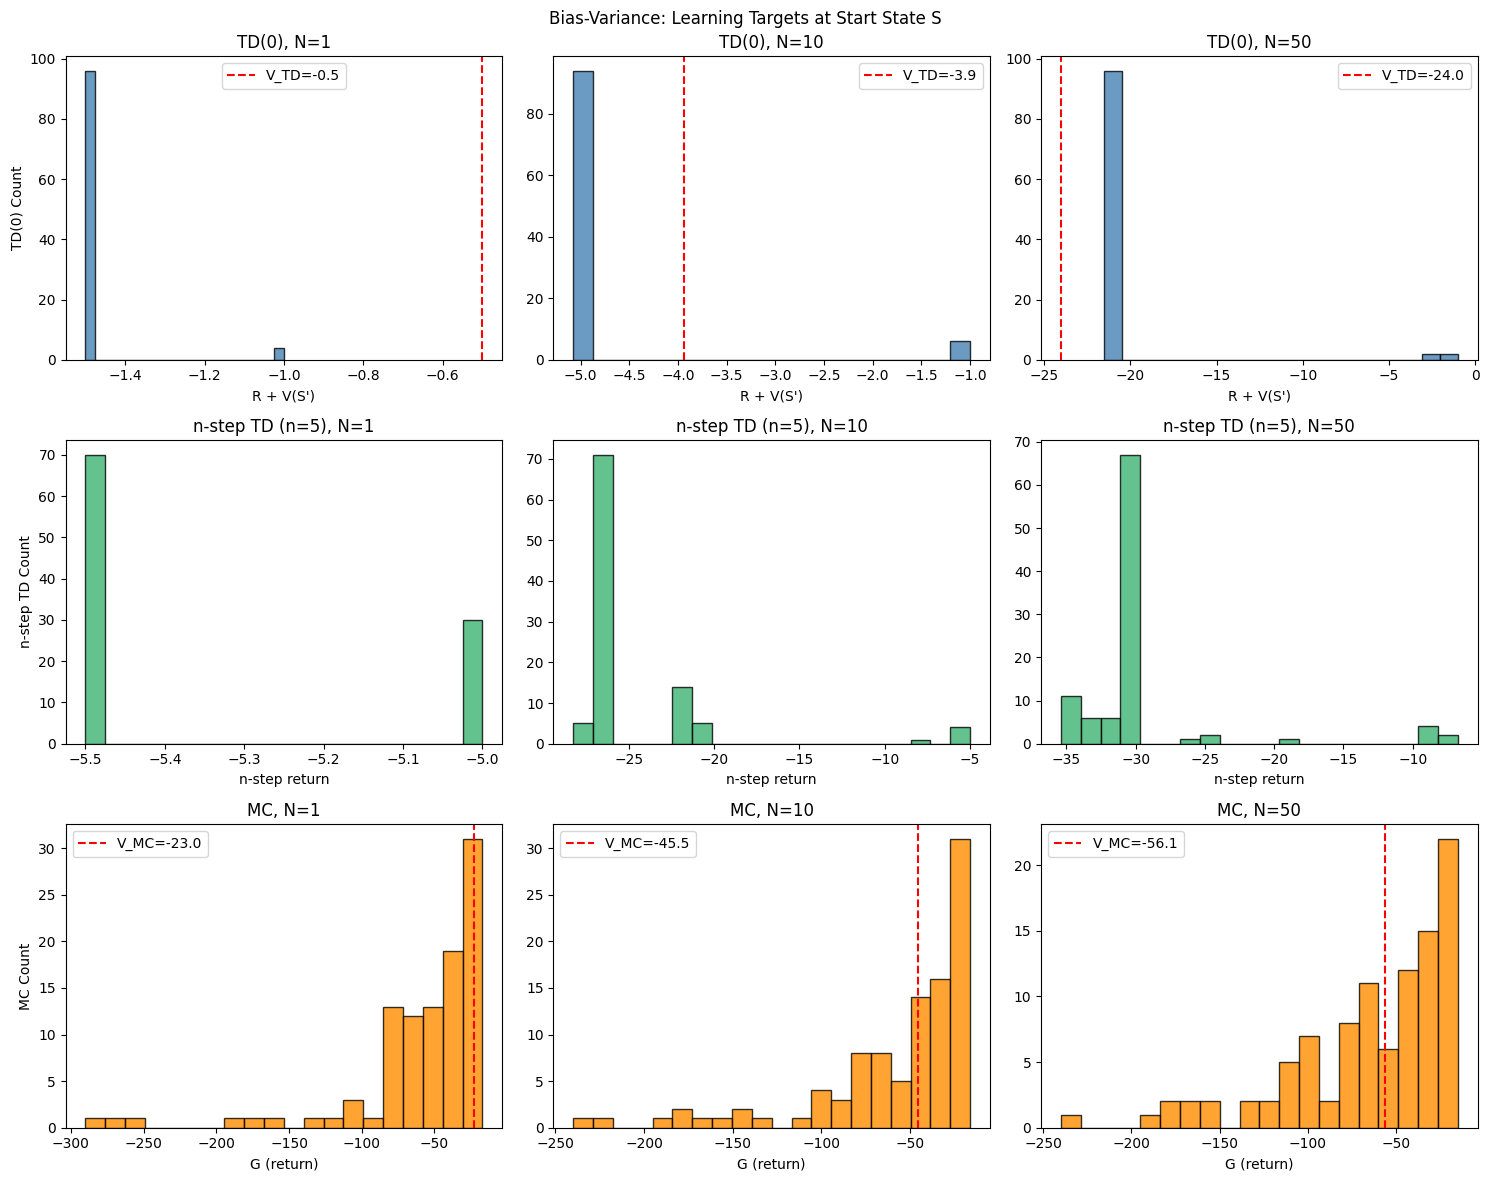

In [14]:
if __name__ == "__main__":
    np.random.seed(1234)
    random.seed(1234)
    run_on_policy_mc_td_epsilon_greedy_windy_gridworld()